## New Species

### At what rate have new species been identified?

In [3]:
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda import COLORS, COLORS_DICT, get_observations_data, nymyc_cmap, nymyc_cmap_r

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

### New Species Accumulation Curve

New species accumulation curve—what’s the rate at which we’re adding new species?
 - What’s the pace of discovery?
 - Be sure to exclude the “sp” (i.e., unknown species; these have been removed in the cleaning/read-in functions in `eda.py`)
 - **IGNORE: the “new to park” and “new to city” fields** (Ethan designed those to be manual, prone to human error)

In [18]:
observations = get_observations_data(compound_dates=True)
observations.head()

,MushroomID,BroadGroupID,Genus,Species,BroadGroupName,WalkDate,Date,Month,Week,Year,Month_Year,Week_Year,Quarter,Quarter_Year
0,300,3.0,Hortiboletus,campestris,Boletes,2009-06-28,2009-06-28,June,26,2009,"June, 2009","Week 26, 2009",2,"Q2, 2009"
1,2329,3.0,Boletus,subvelutipes-complex,Boletes,2009-06-28,2009-06-28,June,26,2009,"June, 2009","Week 26, 2009",2,"Q2, 2009"
2,3,3.0,Cyanoboletus,pulverulentus,Boletes,2009-06-28,2009-06-28,June,26,2009,"June, 2009","Week 26, 2009",2,"Q2, 2009"
3,4,3.0,Gyroporus,castaneus,Boletes,2009-06-28,2009-06-28,June,26,2009,"June, 2009","Week 26, 2009",2,"Q2, 2009"
4,5,3.0,Tylopilus,ferrugineus,Boletes,2009-06-28,2009-06-28,June,26,2009,"June, 2009","Week 26, 2009",2,"Q2, 2009"


In [19]:
# Double-check that all unknown species rows have been removed
observations['Species'].value_counts()

Species
complicatum      553
biforme          422
versicolor       417
olivacea         395
lacteus          378
                ... 
theiodeus          1
fimicola           1
lasioboloides      1
dubia              1
mammulata          1
Name: count, Length: 1280, dtype: int64

In [20]:
observations.loc[(observations['Species'].str.contains('sp.')) | (observations['Species'].str.contains('spp.'))]

,MushroomID,BroadGroupID,Genus,Species,BroadGroupName,WalkDate,Date,Month,Week,Year,Month_Year,Week_Year,Quarter,Quarter_Year


### How to identify a 'new' species identification?

In order to be considered a new species, it can't have been identified before. Obviously the first few months (years?) should be full of new species ID, but after that it should drop and then begin to increase.

**Ideas:**
 - Could maintain a list of species and check each row against it; if not in, `new_sp += 1` and `set(all_sp).add('<sp>')`
 - Just plot the `observations['Species'].nunique()` up to each date
 - Group by `Species` w/min `Date`, then flip df and plot

In [21]:
observations['Species'].nunique()

1280

<Axes: xlabel='Date'>

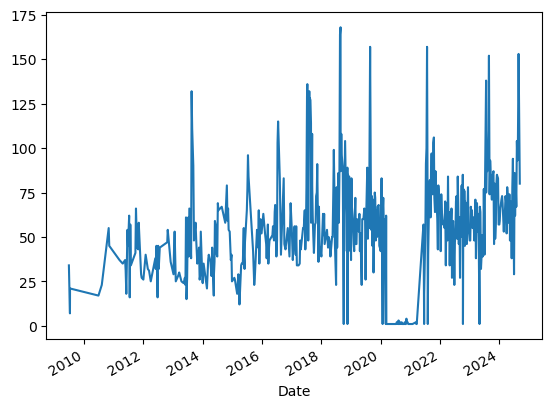

In [22]:
# Simplest version
observations.groupby('Date')['Species'].nunique().plot()

Obligatory drop-off for covid there in 2020-2021.

This isn't really answering the question though--it's showing the number of species identified each date, but not the number of *new* species.

In [35]:
observations['Fullname'] = observations['Genus'].str.strip() + ', ' + observations['Species'].str.strip()

In [41]:
pd.DataFrame(observations.groupby('Fullname').min()['WalkDate']).groupby('WalkDate').count()

""
WalkDate
2009-06-28
2009-07-11
2009-07-12
2010-06-27
2010-08-07
...
2024-08-04
2024-08-10
2024-08-17
